In [32]:
#importss

import csv
import os
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
#Creating CSV file

file_name = "budget_data.csv"

if not os.path.exists(file_name):
    with open(file_name, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Date", "Type", "Amount", "Category"])

print("CSV file ready!")

CSV file ready!


In [18]:
#Adding transaction function

def add_transaction(transaction_type, amount, category):
    date = datetime.now().strftime("%Y-%m-%d")
    
    with open(file_name, mode='a', newline='') as file:
        writer = csv.writer(file)
        writer.writerow([date, transaction_type, amount, category])
        
    print("Transaction added successfully!")

In [20]:
#Viewing transactions

def view_transactions():
    with open(file_name, mode='r') as file:
        reader = csv.reader(file)
        
        for row in reader:
            print(row)

In [38]:
#Calculating balance

def calculate_balance():
    income = 0
    expense = 0
    
    with open(file_name, mode='r') as file:
        reader = csv.DictReader(file)
        
        for row in reader:
            amount = float(row["Amount"])
            
            if row["Type"] == "Income":
                income += amount
            elif row["Type"] == "Expense":
                expense += amount
    
    balance = income - expense
    
    print("Total Income:", income)
    print("Total Expense:", expense)
    print("Current Balance:", balance)

In [35]:
add_transaction("Income", 10000, "Freelance")
add_transaction("Expense", 500, "Food")
add_transaction("Expense", 200, "Travel")

Transaction added successfully!
Transaction added successfully!
Transaction added successfully!


In [57]:
view_transactions()
calculate_balance()

['Date', 'Type', 'Amount', 'Category']
['2026-04-27', 'Income', '10000', 'Freelance']
['2026-04-27', 'Expense', '500', 'Food']
['2026-04-27', 'Expense', '200', 'Travel']
Total Income: 10000.0
Total Expense: 700.0
Current Balance: 9300.0


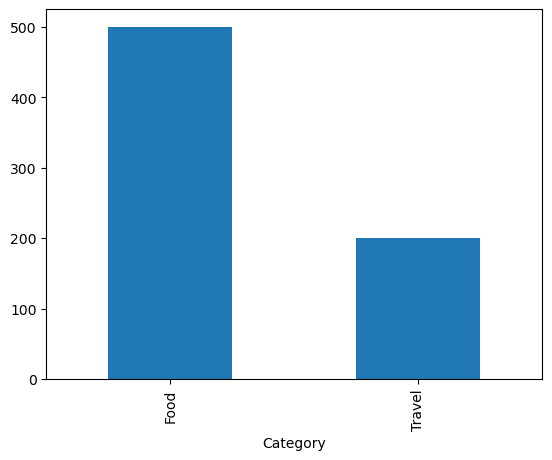

In [28]:
df = pd.read_csv(file_name)

expense_data = df[df["Type"] == "Expense"]

expense_data.groupby("Category")["Amount"].sum().plot(kind="bar")
plt.show()